<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




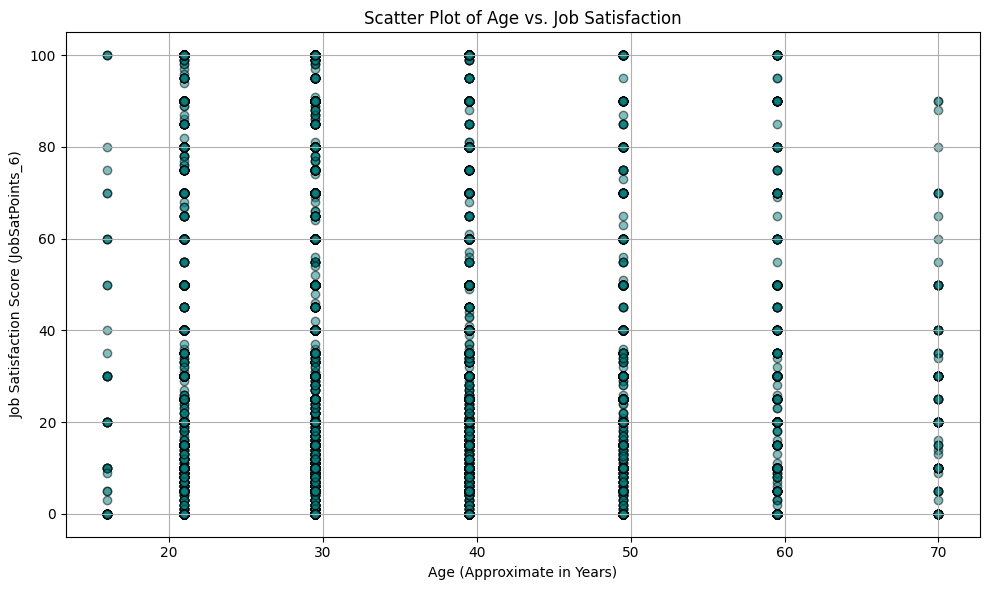

In [3]:
## Write your code here

age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

# Apply the mapping
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop missing values in AgeNumeric and JobSatPoints_6
df_plot = df[['AgeNumeric', 'JobSatPoints_6']].dropna()

# Convert JobSatPoints_6 to numeric (if not already)
df_plot['JobSatPoints_6'] = df_plot['JobSatPoints_6'].astype(float)

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_plot['AgeNumeric'], df_plot['JobSatPoints_6'], alpha=0.5, color='teal', edgecolor='k')
plt.title('Scatter Plot of Age vs. Job Satisfaction')
plt.xlabel('Age (Approximate in Years)')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


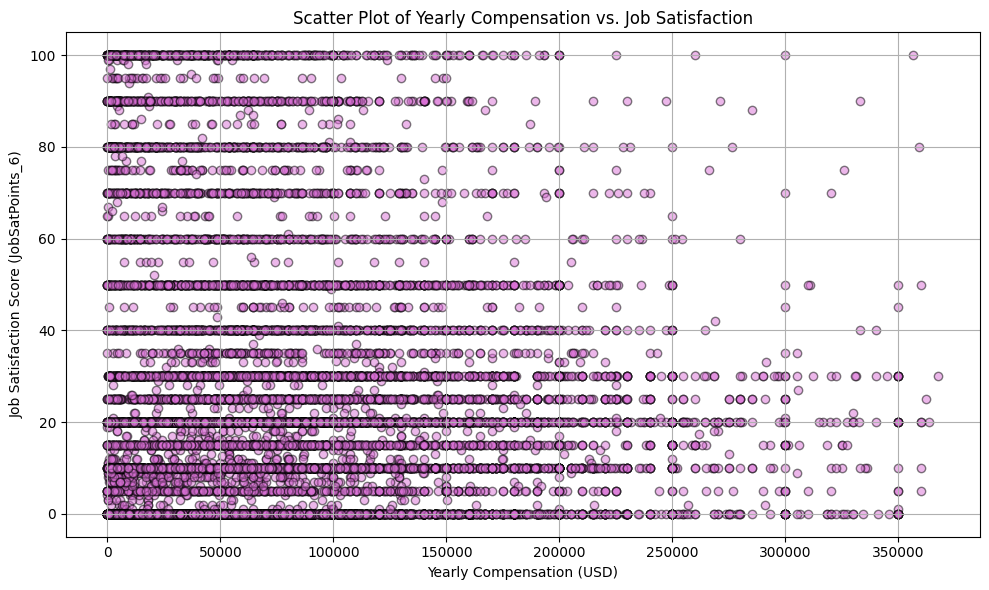

In [5]:
## Write your code here

# Select relevant columns and drop missing values
df_plot = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Convert job satisfaction to numeric (if needed)
df_plot['JobSatPoints_6'] = df_plot['JobSatPoints_6'].astype(float)

# Optional: Remove extreme compensation outliers (e.g., top 1%)
df_plot = df_plot[df_plot['ConvertedCompYearly'] < df_plot['ConvertedCompYearly'].quantile(0.99)]

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_plot['ConvertedCompYearly'], df_plot['JobSatPoints_6'], alpha=0.5, color='orchid', edgecolor='k')
plt.title('Scatter Plot of Yearly Compensation vs. Job Satisfaction')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


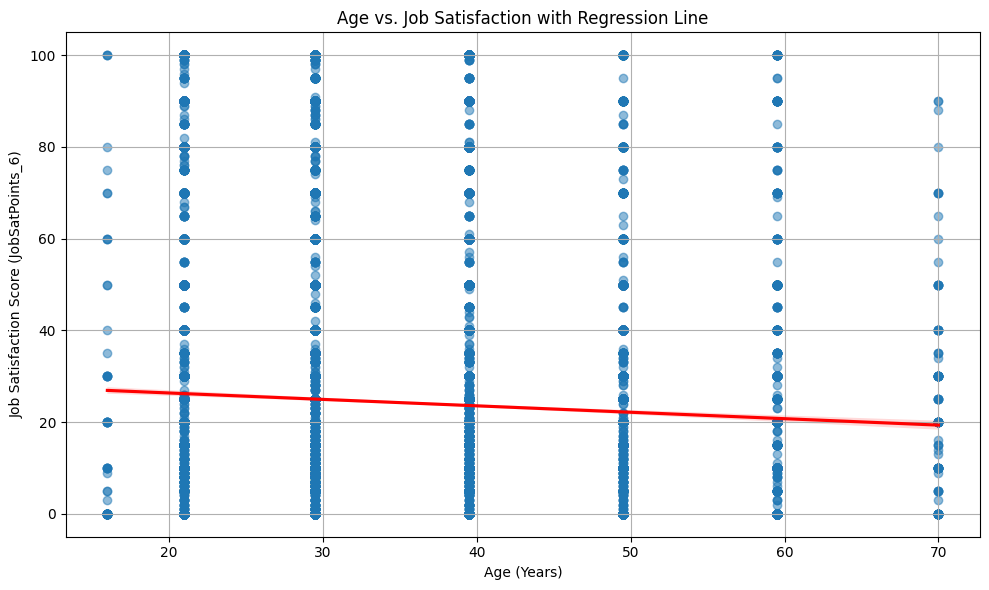

In [7]:
## Write your code here

import seaborn as sns

# Map Age to numeric values
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop missing values
df_plot = df[['AgeNumeric', 'JobSatPoints_6']].dropna()
df_plot['JobSatPoints_6'] = df_plot['JobSatPoints_6'].astype(float)

# Plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='AgeNumeric', y='JobSatPoints_6', data=df_plot, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
plt.title('Age vs. Job Satisfaction with Regression Line')
plt.xlabel('Age (Years)')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


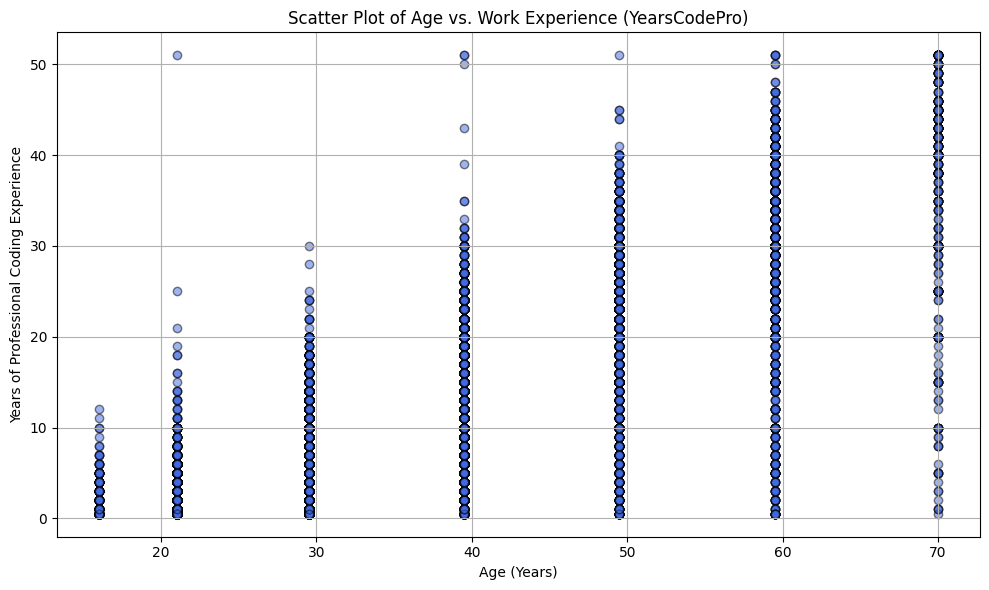

In [8]:
## Write your code here

# Map Age to numeric values
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Replace strings in YearsCodePro and convert to float
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}).astype(float)

# Drop missing values
df_plot = df[['AgeNumeric', 'YearsCodePro']].dropna()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_plot['AgeNumeric'], df_plot['YearsCodePro'], alpha=0.5, color='royalblue', edgecolor='k')
plt.title('Scatter Plot of Age vs. Work Experience (YearsCodePro)')
plt.xlabel('Age (Years)')
plt.ylabel('Years of Professional Coding Experience')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


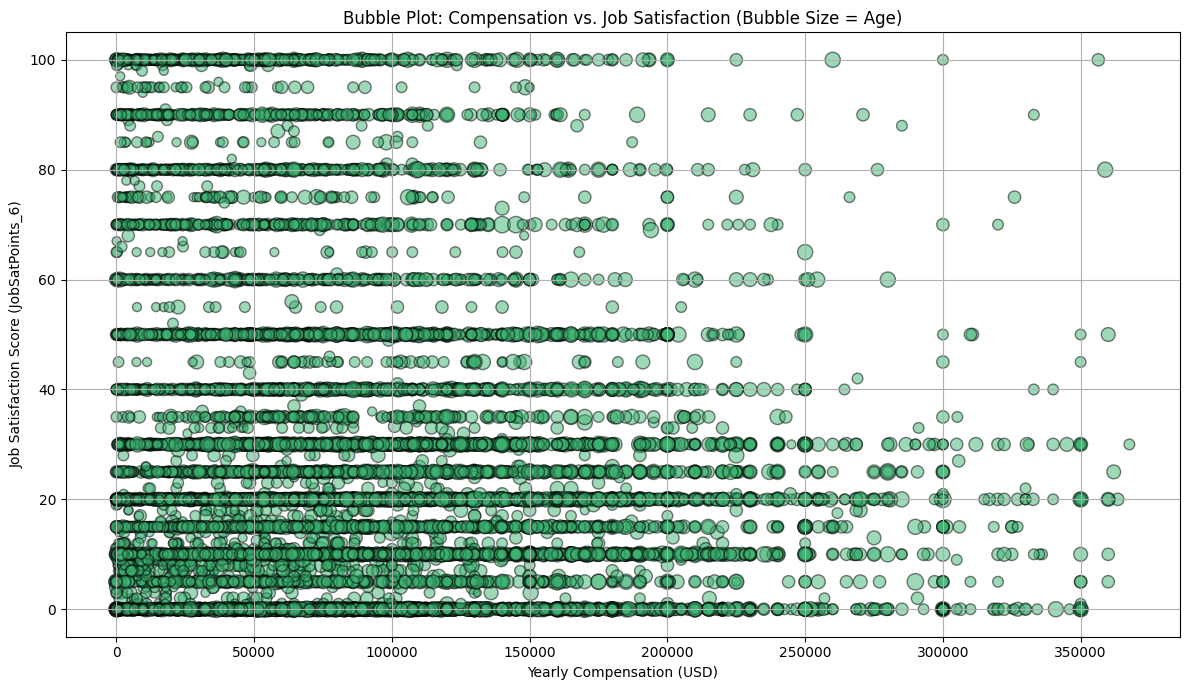

In [9]:
## Write your code here

# Map Age to numeric values for bubble size
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop missing values and convert satisfaction to float
df_plot = df[['ConvertedCompYearly', 'JobSatPoints_6', 'AgeNumeric']].dropna()
df_plot['JobSatPoints_6'] = df_plot['JobSatPoints_6'].astype(float)

# Optional: Filter extreme compensation outliers
df_plot = df_plot[df_plot['ConvertedCompYearly'] < df_plot['ConvertedCompYearly'].quantile(0.99)]

# Bubble plot
plt.figure(figsize=(12, 7))
plt.scatter(
    df_plot['ConvertedCompYearly'],
    df_plot['JobSatPoints_6'],
    s=df_plot['AgeNumeric']*2,  # scale bubble size
    alpha=0.5,
    color='mediumseagreen',
    edgecolor='black'
)
plt.title('Bubble Plot: Compensation vs. Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


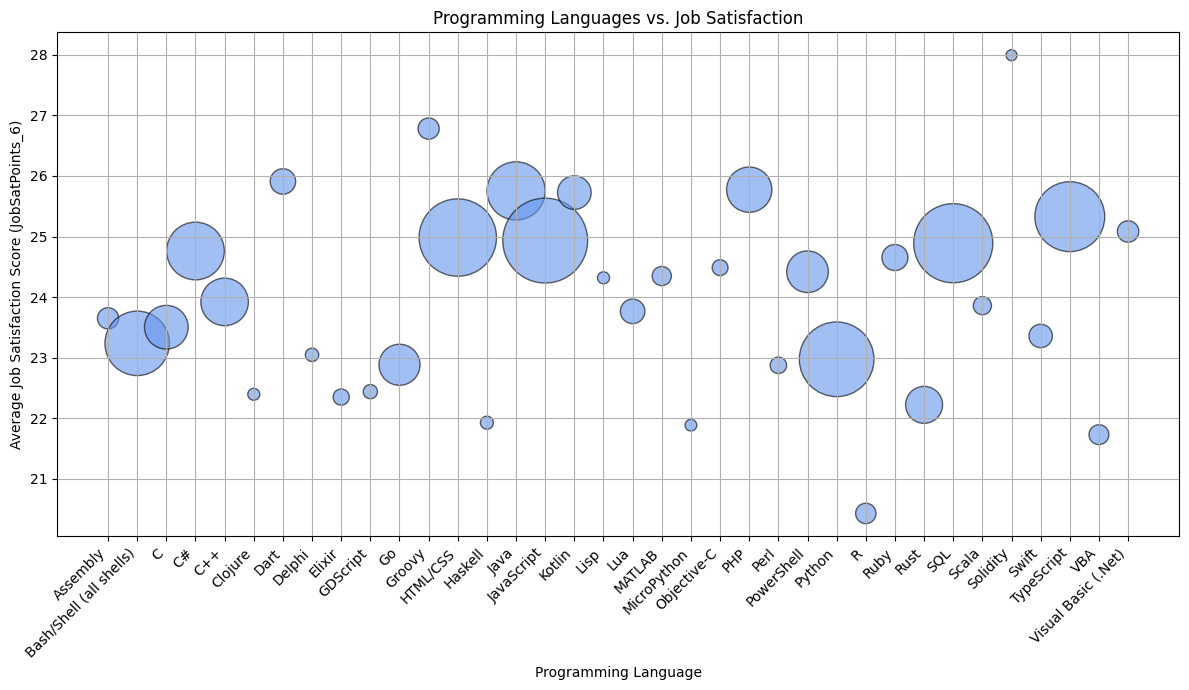

In [10]:
## Write your code here

# Drop rows with missing data
df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()

# Convert JobSatPoints_6 to float
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(float)

# Split languages and explode rows
df_exploded = df.assign(Language=df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
df_exploded['Language'] = df_exploded['Language'].str.strip()

# Group by language and calculate average job satisfaction
lang_sat = df_exploded.groupby('Language')['JobSatPoints_6'].mean().reset_index()
lang_counts = df_exploded['Language'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Count']

# Merge count and satisfaction data
lang_stats = pd.merge(lang_sat, lang_counts, on='Language')

# Optional: Show only languages with enough responses (e.g., > 300)
lang_stats = lang_stats[lang_stats['Count'] > 300]

# Scatter plot
plt.figure(figsize=(12, 7))
plt.scatter(lang_stats['Language'], lang_stats['JobSatPoints_6'], s=lang_stats['Count']*0.2,
            alpha=0.6, color='cornflowerblue', edgecolor='black')
plt.title('Programming Languages vs. Job Satisfaction')
plt.xlabel('Programming Language')
plt.ylabel('Average Job Satisfaction Score (JobSatPoints_6)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [ ]:
## Write your code here

required_cols = ['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']
df = df[[col for col in required_cols if col in df.columns]].dropna()

df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop rows with invalid numeric conversion
df = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'])

df = df[df['ConvertedCompYearly'] < df['ConvertedCompYearly'].quantile(0.99)]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    hue='Employment',
    style='Employment',
    alpha=0.6,
    edgecolor='black'
)

plt.title('Compensation vs. Job Satisfaction by Employment Type')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [ ]:
## Write your code here

df_plot = df[['YearsCodePro', 'Age', 'Country']].dropna()

df_plot = df_plot.dropna(subset=['YearsCodePro'])


# Optional: Standardize age group order for cleaner plot
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]
df_plot = df_plot[df_plot['Age'].isin(age_order)]
df_plot['Age'] = pd.Categorical(df_plot['Age'], categories=age_order, ordered=True)

# Step 4: Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_plot,
    x='Age',
    y='YearsCodePro',
    hue='Country',
    style='Age',
    palette='tab10',
    s=100,
    alpha=0.7
)

plt.title('Work Experience vs. Age Group by Country')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
